In [ ]:
"""This code cleans and visualizes student performance data by handling missing values and plotting boxplots to detect outliers in numeric features."""


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

In [2]:
data = {
    'Student_ID': [1,2,3,4,5,6,7,8,9,10],
    'Name': ['Ram', 'Mohan', 'Sohan', 'rahul', 'geeta', 'john', 'charlie', 'sahil', 'george', 'david'],
    'Age': [20, 21, 19, 22, 20, 21, 19, 22, 20, 21],
    'Math_Score': [88, 92, 85, np.nan, 78, 95, 89, 77, 82, 90],
    'Science_Score': [92, 88, 84, 87, 91, np.nan, 85, 89, 83, 88],
    'English_Score': [85, 90, 88, 86, 84, 89, 91, 87, 85, np.nan],
    'Attendance_Percentage': [95, 96, 93, 94, 92, 91, 90, 89, 88, 87]
}

In [3]:
df = pd.DataFrame(data)

In [4]:
df.head()

,Student_ID,Name,Age,Math_Score,Science_Score,English_Score,Attendance_Percentage
0,1,Ram,20,88.0,92.0,85.0,95
1,2,Mohan,21,92.0,88.0,90.0,96
2,3,Sohan,19,85.0,84.0,88.0,93
3,4,rahul,22,NaN,87.0,86.0,94
4,5,geeta,20,78.0,91.0,84.0,92


In [5]:
print(df.isnull().sum())

Student_ID               0
Name                     0
Age                      0
Math_Score               1
Science_Score            1
English_Score            1
Attendance_Percentage    0
dtype: int64


In [6]:
df['Math_Score'].fillna(df['Math_Score'].mean(), inplace=True)
df['Science_Score'].fillna(df['Science_Score'].mean(), inplace=True)
df['English_Score'].fillna(df['English_Score'].mean(), inplace=True)

C:\Users\singh\AppData\Local\Temp\ipykernel_18496\3084311005.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Math_Score'].fillna(df['Math_Score'].mean(), inplace=True)
C:\Users\singh\AppData\Local\Temp\ipykernel_18496\3084311005.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

In [7]:
print(df.isnull().sum())

Student_ID               0
Name                     0
Age                      0
Math_Score               0
Science_Score            0
English_Score            0
Attendance_Percentage    0
dtype: int64


In [8]:
print(df)

   Student_ID     Name  Age  Math_Score  Science_Score  English_Score  \
0           1      Ram   20   88.000000      92.000000      85.000000   
1           2    Mohan   21   92.000000      88.000000      90.000000   
2           3    Sohan   19   85.000000      84.000000      88.000000   
3           4    rahul   22   86.222222      87.000000      86.000000   
4           5    geeta   20   78.000000      91.000000      84.000000   
5           6     john   21   95.000000      87.444444      89.000000   
6           7  charlie   19   89.000000      85.000000      91.000000   
7           8    sahil   22   77.000000      89.000000      87.000000   
8           9   george   20   82.000000      83.000000      85.000000   
9          10    david   21   90.000000      88.000000      87.222222   

   Attendance_Percentage  
0                     95  
1                     96  
2                     93  
3                     94  
4                     92  
5                     91  
6      

In [9]:
numeric_columns = ['Age', 'Math_Score', 'Science_Score', 'English_Score', 'Attendance_Percentage']

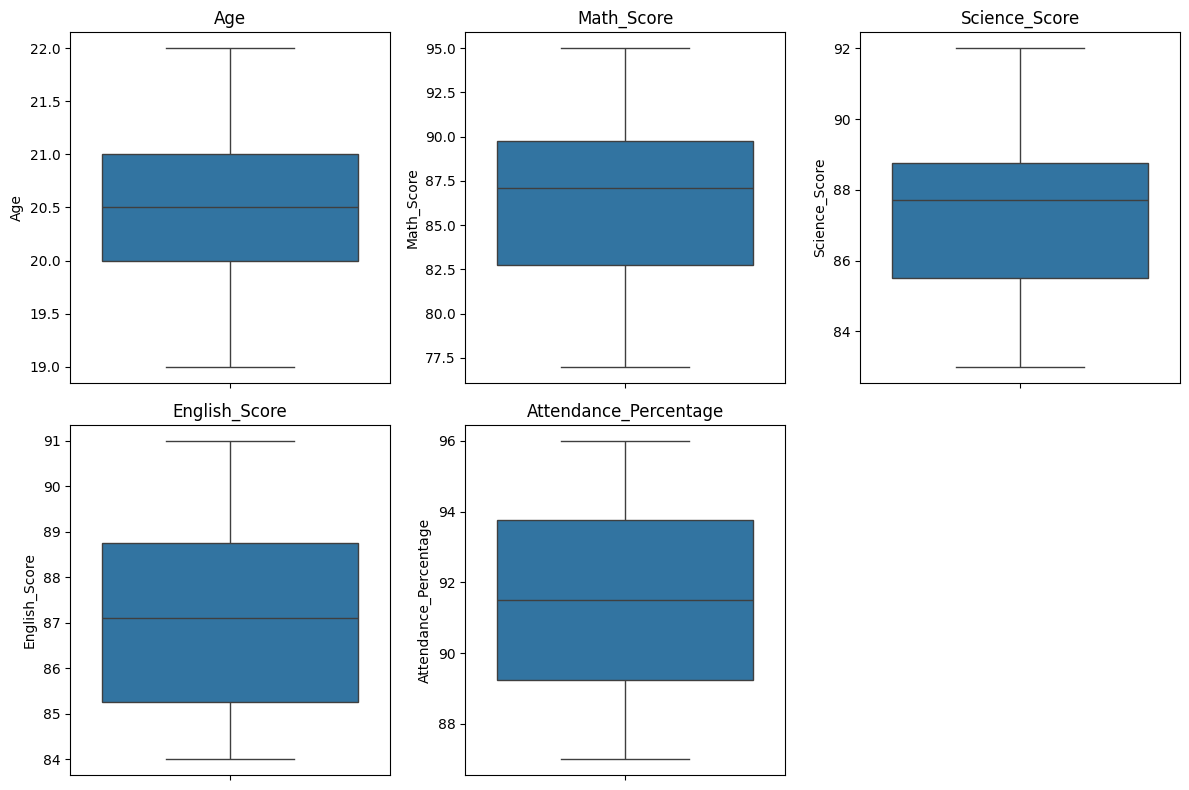

In [10]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [ ]:
"""2.1 Importing Required Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
pandas: For creating and manipulating DataFrames.

numpy: For handling numerical data and special values like NaN.

seaborn: For creating attractive statistical visualizations.

matplotlib.pyplot: For plotting graphs.

zscore: A function from scipy.stats to detect outliers using standard score (although it's not used in this code).

2.2 Creating a Student Dataset

data = {
    'Student_ID': [1,2,3,4,5,6,7,8,9,10],
    'Name': ['Ram', 'Mohan', 'Sohan', 'rahul', 'geeta', 'john', 'charlie', 'sahil', 'george', 'david'],
    'Age': [20, 21, 19, 22, 20, 21, 19, 22, 20, 21],
    'Math_Score': [88, 92, 85, np.nan, 78, 95, 89, 77, 82, 90],
    'Science_Score': [92, 88, 84, 87, 91, np.nan, 85, 89, 83, 88],
    'English_Score': [85, 90, 88, 86, 84, 89, 91, 87, 85, np.nan],
    'Attendance_Percentage': [95, 96, 93, 94, 92, 91, 90, 89, 88, 87]
}
A dictionary named data is created with academic and demographic information of 10 students.

It includes Student_ID, Name, Age, three subject scores, and Attendance_Percentage.

Some values for Math_Score, Science_Score, and English_Score are intentionally left missing (np.nan).


df = pd.DataFrame(data)
Converts the dictionary into a structured tabular format (DataFrame) using pandas.


df.head()
Displays the first 5 rows of the DataFrame (in a Jupyter Notebook or similar, not printed in a script unless using print()).

2.3 Checking for Missing Values

print(df.isnull().sum())
Checks each column for missing values (NaN) and prints the count.

Helps in identifying which columns need data cleaning.

2.4 Replacing Missing Values with Mean

df['Math_Score'].fillna(df['Math_Score'].mean(), inplace=True)
df['Science_Score'].fillna(df['Science_Score'].mean(), inplace=True)
df['English_Score'].fillna(df['English_Score'].mean(), inplace=True)
Fills the missing values in each subject score column with the mean of the respective column.

inplace=True makes the changes directly to the DataFrame without needing reassignment.

This is a common technique called mean imputation, which avoids losing data due to missing entries.

2.5 Verifying Cleaning and Printing the Data

print(df.isnull().sum())
Verifies that all missing values have been replaced (should print 0 for all columns).


print(df)
Prints the cleaned and completed DataFrame so you can visually inspect the imputed values.

2.6 Preparing for Outlier Visualization

numeric_columns = ['Age', 'Math_Score', 'Science_Score', 'English_Score', 'Attendance_Percentage']
Creates a list of numeric features for which outlier detection and visualization will be performed.

These are continuous variables suitable for boxplots.

2.7 Plotting Boxplots for Outliers

plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()
Initializes a large plotting area (12x8 inches).

Iterates through the list of numeric columns and:

Creates a subplot for each column.

Draws a boxplot (a statistical plot that shows median, quartiles, and potential outliers).

Titles each plot with the column name.

plt.tight_layout() avoids overlapping subplots.

plt.show() renders the complete figure.

The boxplots help you visually identify outliers, which are data points lying significantly outside the normal range."""